<a href="https://colab.research.google.com/github/mingshey/python_EM/blob/main/MoM_LorentzForce_PointCharge_StaggeredGrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-----

## MoM (Method of Moments) 시뮬레이션: 점전하 분포 및 스태거드 그리드 (최종 버전)

이 Colab 노트북은 로렌츠 힘에 의해 유도된 전기장을 상쇄하기 위해 도체 막대에 유도되는 전하 분포를 모멘트 방법(Method of Moments, MoM)을 사용하여 계산합니다. 특히, **점전하(Point Charge) 분포를 기저 함수(Basis Function)로 사용하고, 전기장 평가를 위해 스태거드 그리드(Staggered Grid) 방식을 채택**합니다.

### 1\. 이론적 배경

#### 1.1 문제 정의

x-방향으로 길이 $L$인 가는 도체 막대가 y-방향의 균일한 자기장 $\mathbf{B}$ 안에서 z-방향으로 일정한 속도 $\mathbf{v}$로 움직이고 있습니다. 이 경우, 막대 내부의 전하에 로렌츠 힘 $\mathbf{F} = q(\mathbf{v} \times \mathbf{B})$이 작용하여 전하 분리가 발생하고, 결과적으로 유도 전기장 $\mathbf{E}_{\rm induced} = -\mathbf{v} \times \mathbf{B}$가 생성됩니다. 도체 막대 내부에서는 평형 상태에서 총 전기장이 0이 되어야 하므로, 유도된 전하 분포 $\lambda(x)$에 의해 발생하는 전기장 $\mathbf{E}_{\rm charge}$가 $\mathbf{E}_{\rm induced}$를 상쇄해야 합니다:
$$\mathbf{E}_{\rm total}(x) = \mathbf{E}_{\rm induced} + \mathbf{E}_{\rm charge}(x) = 0$$
따라서, $\mathbf{E}_{\rm charge}(x) = -\mathbf{E}_{\rm induced}$를 만족하는 전하 분포 $\lambda(x)$를 찾는 것이 목표입니다.

#### 1.2 모멘트 방법 (Method of Moments, MoM)

MoM은 미분/적분 방정식을 대수 방정식 시스템으로 변환하여 푸는 수치 해석 기법입니다.

1.  **전하 밀도 근사**: 우리가 찾고자 하는 미지의 전하 밀도 $\lambda(x)$를 $N$개의 \*\*점전하(point charge)\*\*들의 배열로 근사합니다. 각 점전하 $Q_j$는 $j$번째 기저 함수 $f_j(x')$ (여기서는 델타 함수)의 계수입니다:
  $$\lambda(x') \approx \sum_{j=1}^{N} Q_j \delta(x' - x_j)$$
  여기서 $Q_j$는 우리가 결정해야 할 미지의 전하량입니다.

2.  **전기장 계산**: 각 점전하 $Q_j$가 만드는 전기장 $\mathbf{E}_j(x)$는 쿨롱 법칙에 의해 다음과 같이 주어집니다:
  $$\mathbf{E}_{\rm charge}(x) = \sum_{j=1}^{N} Q_j \mathbf{E}_{j}(x)$$
  여기서 $\mathbf{E}_j(x)$는 단위 전하량($Q_j=1$)을 가진 $j$번째 점전하가 $x$ 지점에 만드는 전기장입니다.

3.  **콜로케이션 (Collocation)**: 도체 내부의 $M$개의 특정 평가 지점(test points) $x_i$에서 총 전기장이 0이라는 조건을 적용합니다:
  $$\mathbf{E}_{\rm induced}(x_i) + \sum_{j=1}^{N} Q_j \mathbf{E}_{j}(x_i) = 0 \quad \text{for } i=1, \dots, M$$
    이를 행렬 형태로 표현하면 다음과 같습니다:
  $$\mathbf{Z} \mathbf{Q} = -\mathbf{E}_{\rm induced}$$
  여기서 $\mathbf{Z}$는 $M \times N$ 크기의 임피던스 행렬(Impedance Matrix)로, $Z_{ij} = \mathbf{E}*j(x_i)$입니다. $\mathbf{Q}$는 미지의 전하량 벡터, $\mathbf{E}_{\rm induced}$는 각 평가 지점에서의 유도 전기장 벡터입니다.

4.  **선형 시스템 해법**: 이 선형 방정식을 풀어 $Q_j$ 전하량들을 구하고, 이를 통해 전하 분포 $\lambda(x)$를 재구성합니다.

#### 1.4 점전하와 스태거드 그리드 (Staggered Grid)

  * **점전하의 전기장:** $j$번째 점전하 $Q_j$가 위치 $x_j$에 있을 때, 평가 지점 $x_i$에서 만드는 전기장 $E_x(x_i)$의 크기는 다음과 같습니다 (여기서 $r = x_i - x_j$):
  $$E_x(x_i) = \frac{1}{4\pi\epsilon_0} \frac{x_i - x_j}{|x_i - x_j|^3}$$
    점전하 모델은 $x_i = x_j$일 때 전기장이 무한대로 발산하는 **특이점(singularity)** 문제가 발생합니다.

  * **스태거드 그리드:** 이 특이점 문제를 해결하기 위해 **스태거드 그리드**(엇갈린 격자)를 사용합니다:

      * **전하 기저 함수 위치 ($x_{\rm charge\\_basis\\_centers}$)**: 막대를 $N$개의 세그먼트로 나누고, 각 세그먼트의 **중심**에 점전하를 배치합니다.
          * $x_j = (j-0.5) \cdot dx_{\rm segment}$ (여기서 $j$는 1부터 $N$까지)
      * **전기장 평가 지점 ($x_{\rm field\\_points}$)**: 전기장을 평가하는 지점은 각 세그먼트의 **경계**에 둡니다.
          * $x_i = i \cdot dx_{\rm segment}$ (여기서 $i$는 1부터 $N-1$까지)
            이렇게 전하 위치와 전기장 평가 지점을 서로 엇갈리게 배치하면, **어떤 전하의 위치도 전기장 평가 지점과 겹치지 않게 됩니다.** 즉, $x_i - x_j$가 0이 될 일이 원천적으로 없어지므로, 쿨롱 법칙 공식에서 발생하는 특이점 문제를 효과적으로 회피하고, Z 행렬의 안정성을 크게 높일 수 있습니다. 따라서, `calculate_Ex_from_point_charge` 함수 내에서 `r=0`일 때의 예외 처리가 필요 없습니다.

### 2\. 코드 설명

다음 Python 코드는 위에서 설명한 MoM 알고리즘을 구현합니다.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d # 시각화를 위한 필터 (선택 사항)

In [ ]:
# --- 1. 물리 상수 및 문제 변수 설정 ---
epsilon_0 = 8.854e-12  # 진공의 유전율 (F/m)
v = 1.0              # 막대의 속도 (m/s)
B = 1.0              # 자기장 세기 (T)
L = 1.0              # 막대의 길이 (m)

# 로렌츠 힘에 의해 유도되는 전기장 (막대 길이 방향)
E_induced_value = v * B # -1.0 V/m

print(f"Lorentz-induced Electric Field (E_induced): {E_induced_value:.4e} V/m")

Lorentz-induced Electric Field (E_induced): 1.0000e+00 V/m


In [ ]:
# --- 2. MoM 시뮬레이션 설정 ---
N = 100              # 점전하의 수 (기저 함수의 수)
dx_segment = L / N   # 각 세그먼트의 길이

# 2.1. 점전하가 위치할 중심 위치 (x축 상)
x_charge_basis_centers = np.linspace(dx_segment / 2, L - dx_segment / 2, N)
N_charge = N # 점전하의 수는 N과 동일

# 2.2. 전기장 E가 평가될 위치 (x축 상) - 스태거드 그리드(staggered grid) 적용
# N개의 전하가 있으면 N-1개의 내부 경계에 전기장 평가 지점을 둡니다.
x_field_points = np.linspace(dx_segment, L - dx_segment, N - 1)
N_field = N - 1 # 전기장 평가 지점의 수 (내부 경계 수)

# 전하 밀도 재구성을 위한 평가 지점 (점전하의 위치와 동일)
x_charge_points = x_charge_basis_centers

print(f"Number of point charges (N_charge): {N_charge}")
print(f"Number of field evaluation points (N_field): {N_field}")

# 외부 유도 전기장 벡터 (전기장 평가 지점 수만큼)
E_induced_vector = np.full(N_field, E_induced_value)

Number of point charges (N_charge): 100
Number of field evaluation points (N_field): 99


In [ ]:
# --- 3. Z 행렬 (쿨롱 상호 작용 행렬) 구성 ---
# Z_ij: j번째 점전하(단위 전하)가 i번째 전기장 평가 지점에 만드는 전기장
Z_matrix_coulomb = np.zeros((N_field, N_charge))

# 점전하에 의한 전기장 함수
def calculate_Ex_from_point_charge(x_eval_point, x_charge_point):
    """
    x축 상의 전기장 평가 지점에서 x축 상의 점전하에 의한
    전기장(x-성분)을 계산합니다. (단위 전하 Q=1 기준)
    스태거드 그리드를 사용하므로 x_eval_point == x_charge_point인 경우는 발생하지 않습니다.
    """
    r = x_eval_point - x_charge_point # 거리 벡터의 x 성분

    # 쿨롱 법칙에 따른 전기장 크기 (Q=1)
    # E = (1 / (4*pi*eps0)) * (1/r^2)
    # E_x = E * (r / |r|) = (1 / (4*pi*eps0)) * (r / |r|^3)
    # 쿨롱 상수는 나중에 Z_matrix_scaled_coulomb에서 곱함
    Ex_component = r / (np.abs(r)**3)

    return Ex_component

print("Constructing Coulomb Z-matrix (MoM with Point Charge Basis - Staggered Grid)... This might take a moment.")
for i in range(N_field): # 전기장 평가 지점 (행)
    for j in range(N_charge): # 점전하 (열)
        # 스태거드 그리드를 사용하므로 특이점 발생 가능성이 없음
        Z_matrix_coulomb[i, j] = calculate_Ex_from_point_charge(
            x_field_points[i], x_charge_basis_centers[j]
        )

# 쿨롱 상수를 Z 행렬에 곱하여 물리적 단위를 맞춥니다.
Z_matrix_scaled_coulomb = Z_matrix_coulomb / (4 * np.pi * epsilon_0)

Constructing Coulomb Z-matrix (MoM with Point Charge Basis - Staggered Grid)... This might take a moment.


In [ ]:
# --- 4. Moment 방법: 선형 연립 방정식 풀이 (최소 제곱법 사용) ---
# Z_matrix_scaled_coulomb @ charge_coeffs = -E_induced_vector
# 여기서 charge_coeffs는 각 점전하의 전하량입니다.
print("Solving for point charge coefficients using MoM (least squares)...")
try:
    charge_coeffs, residuals, rank, s = np.linalg.lstsq(Z_matrix_scaled_coulomb, -E_induced_vector, rcond=None)
    print(f"Least squares solution found. Residuals (sum of squares): {residuals.item() if residuals.size > 0 else 0.0:.4e}, Rank: {rank}")
except np.linalg.LinAlgError as e:
    print(f"Error solving linear system with lstsq: {e}")
    print("This usually means the Z-matrix is singular or ill-conditioned.")
    print("Try adjusting 'N' or check matrix construction.")
    charge_coeffs = np.full(N_charge, np.nan) # 오류 발생 시 nan으로 채움

print("MoM simulation finished.")

Solving for point charge coefficients using MoM (least squares)...
Least squares solution found. Residuals (sum of squares): 0.0000e+00, Rank: 99
MoM simulation finished.


In [ ]:
# --- 5. 최종 전하 밀도 람다(x) 재구성 ---
# charge_coeffs는 각 점전하의 전하량 그 자체이므로,
# 이를 각 점전하 위치에서의 선 전하 밀도로 변환합니다 (람다 = Q / 세그먼트 길이).
final_lambda = charge_coeffs / dx_segment

In [ ]:
# --- 6. 전하 밀도 시각화를 위한 가우시안 필터 적용 (옵션 - 주석 처리) ---
# 점전하의 경우 플롯에서 매우 뾰족하게 나타나 시각적 부드러움을 위해 필터를 사용했으나,
# 결과의 정확성에는 영향을 주지 않으므로 필요에 따라 사용 여부 결정.
# 여기서는 원본 데이터를 그대로 보여줍니다.
# gaussian_sigma_for_plot = 2.0
# if not np.isnan(final_lambda).all():
#     final_lambda_smoothed = gaussian_filter1d(final_lambda, sigma=gaussian_sigma_for_plot, mode='nearest')
# else:
#     final_lambda_smoothed = np.full_like(final_lambda, np.nan)
# print(f"Applied Gaussian filter (for plotting) to final lambda with sigma = {gaussian_sigma_for_plot}")
# smoothed_plotting_enabled = True # 필터링된 플롯을 그릴지 여부

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-2887907095.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.axhline(y=0, color='k', linestyle='--', label='Initial $\lambda(x) = 0$ (equilibrium)')
/tmp/ipython-input-2887907095.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_charge_points, final_lambda, 'b-', markersize=4, color='blue', label='Final $\lambda(x)$ (Q/dx_segment)')
/tmp/ipython-input-2887907095.py:15: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Line Charge Density Distrib

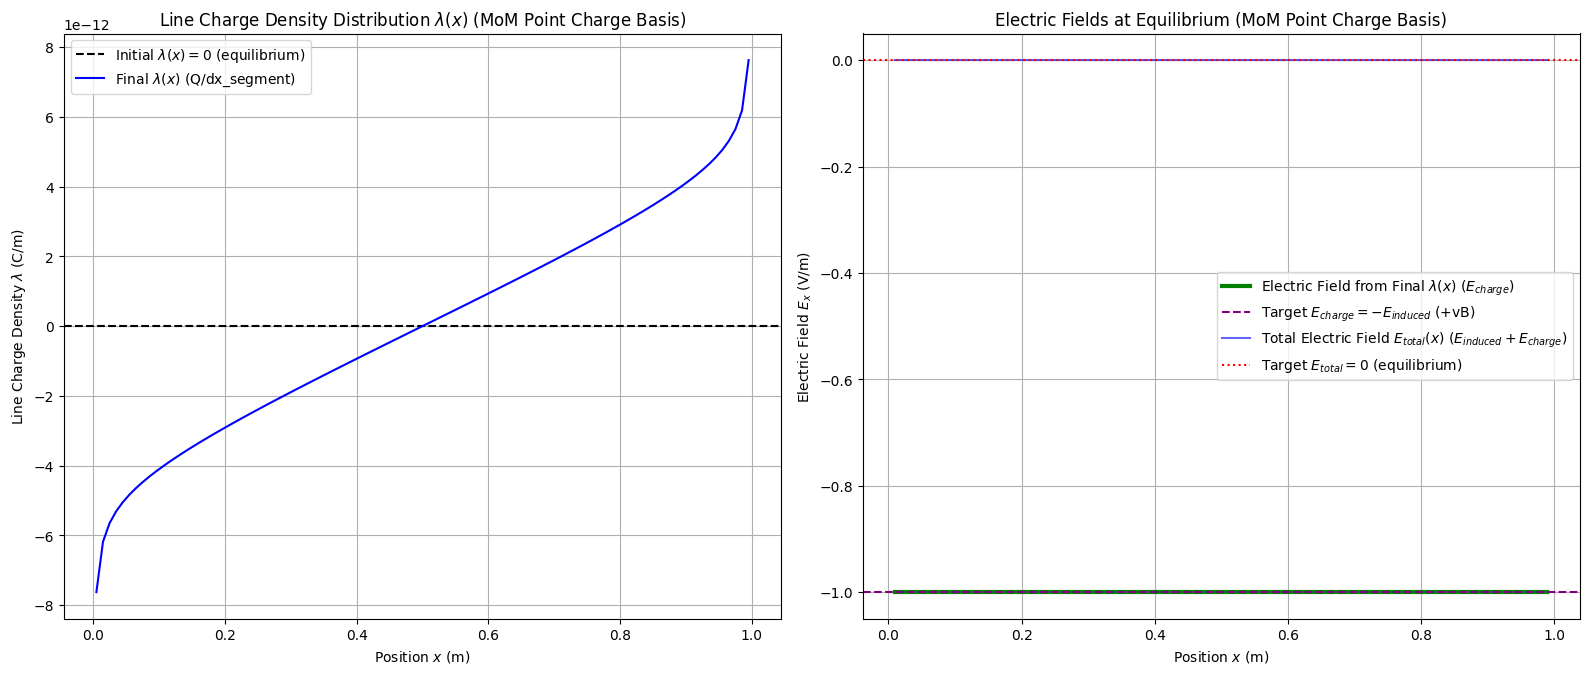

In [ ]:
# --- 7. 결과 시각화 ---
plt.figure(figsize=(16, 7))

# 7.1. 전하 밀도 분포 플롯
plt.subplot(1, 2, 1)
plt.axhline(y=0, color='k', linestyle='--', label='Initial $\lambda(x) = 0$ (equilibrium)')
# 점전하이므로 'o' 마커로 각 지점의 전하량을 표시하는 것이 적합
plt.plot(x_charge_points, final_lambda, 'b-', markersize=4, color='blue', label='Final $\lambda(x)$ (Q/dx_segment)')

# 필터링된 플롯을 원한다면 다음 줄의 주석을 해제하세요.
# if smoothed_plotting_enabled:
#     plt.plot(x_charge_points, final_lambda_smoothed, color='red', linestyle='--', linewidth=2, label=f'Final $\lambda(x)$ (Plot Smoothed, $\sigma$={gaussian_sigma_for_plot})')


plt.title('Line Charge Density Distribution $\lambda(x)$ (MoM Point Charge Basis)')
plt.xlabel('Position $x$ (m)')
plt.ylabel('Line Charge Density $\lambda$ (C/m)')
plt.legend()
plt.grid(True)

# 7.2. 최종 전하 밀도에 의한 전기장 및 총 전기장 플롯
plt.subplot(1, 2, 2)
if not np.isnan(charge_coeffs).all():
    # E_charge는 Z 행렬과 charge_coeffs를 직접 곱하여 계산
    E_charge_final = np.dot(Z_matrix_scaled_coulomb, charge_coeffs)
    E_total_final = E_induced_value + E_charge_final

    # 전기장 플롯은 필터링이 필요 없음 (이미 매우 부드럽고 정확함)
    # E_charge_smoothed_for_plot = gaussian_filter1d(E_charge_final, sigma=gaussian_sigma_for_plot, mode='nearest')
else:
    E_charge_final = np.full(N_field, np.nan)
    E_total_final = np.full(N_field, np.nan)
    # E_charge_smoothed_for_plot = np.full(N_field, np.nan)


plt.plot(x_field_points, E_charge_final, 'g-', linewidth=3, label='Electric Field from Final $\lambda(x)$ ($E_{{charge}}$)')
# 필터링된 전기장 플롯을 원한다면 다음 줄의 주석을 해제하세요.
# if smoothed_plotting_enabled:
#     plt.plot(x_field_points, E_charge_smoothed_for_plot, 'c:', linewidth=2, label=f'Electric Field (Plot Smoothed, $\sigma$={gaussian_sigma_for_plot})')

plt.axhline(y=-E_induced_value, color='purple', linestyle='--', label='Target $E_{{charge}} = -E_{{induced}}$ (+vB)')
plt.plot(x_field_points, E_total_final, 'b-', alpha=0.6, label='Total Electric Field $E_{{total}}(x)$ ($E_{{induced}} + E_{{charge}}$)')
plt.axhline(y=0, color='red', linestyle=':', label='Target $E_{{total}} = 0$ (equilibrium)')

plt.title('Electric Fields at Equilibrium (MoM Point Charge Basis)')
plt.xlabel('Position $x$ (m)')
plt.ylabel('Electric Field $E_x$ (V/m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:71: SyntaxWarning: invalid escape sequence '\l'
<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:71: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-181404259.py:60: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_charge_points, final_lambda, 'o', markersize=4, color='blue', alpha=0.7, label='Simulated $\lambda(x)$ (Point Charges)', zorder=5)
/tmp/ipython-input-181404259.py:65: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_fit, fitted_lambda_dense, 'r-', alpha = 0.5, linewidth=2, label=f'Fitted $\lambda(x) = {A_combined:.2g} x + {B_combined:.2g} \\frac{{x}}{{\\sqrt{{1-x^2}}}}$')
/tmp/ipython-input-181404259.py:71: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Line Charge Density $\lambda$ (C/m)')



--- Attempting to fit final_lambda(x) to Linear + 1/sqrt(R) Combined Function ---
Combined fit parameters: A=4.2755e-12, B=4.9824e-13


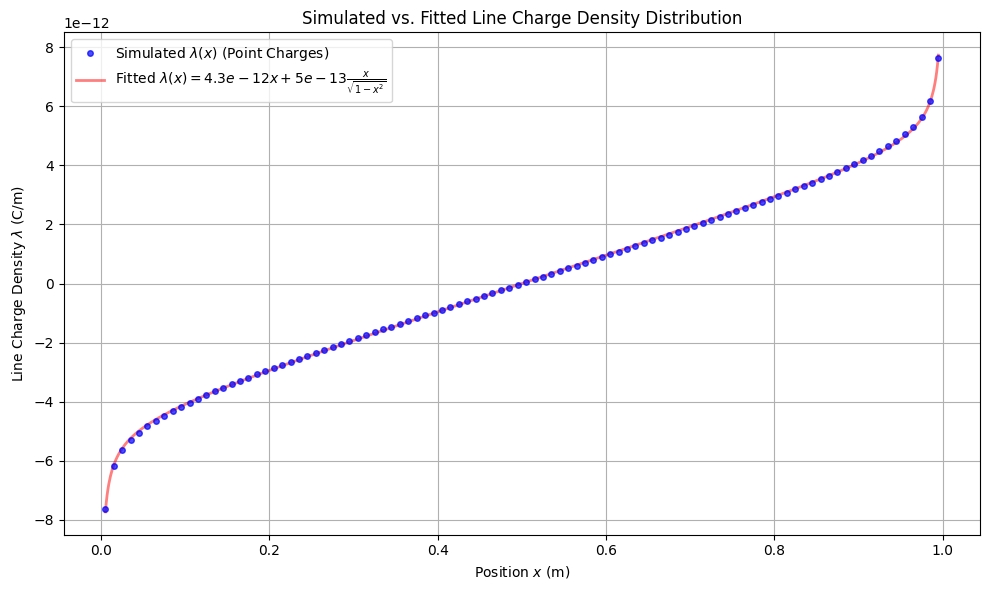

RMSE for Combined fit: 3.4085e-14


In [ ]:
# --- 7.3. final_lambda(x)를 선형 + 1/sqrt(R) 결합 함수에 피팅 ---

# 데이터를 0에서 1 사이로 정규화 (막대 중앙을 0, 끝단을 -1과 1로 매핑)
x_normalized = (x_charge_points - L / 2) / (L / 2)

# 피팅할 결합 함수 정의: y = A*x + B_val * (1/sqrt(1-x_val) - 1/sqrt(1+x_val))
# x_val은 -1 ~ 1 사이의 값 (정규화된 x)
# 작은 epsilon_offset을 추가하여 분모가 0이 되는 것을 방지합니다.
# 이 epsilon_offset은 실제 물리적 의미보다는 수치적 안정성을 위한 값입니다.
def fit_linear_sqrt_R_combined(x_val, A, B, epsilon_offset=1e-6): # epsilon_offset을 파라미터로 두는 대신 상수로
    # 1 - x_val^2 은 끝단에 가까울수록 0이 되고, sqrt(1 - x_val^2)은 발산 형태를 줍니다.
    # 양 끝에서 대칭적인 발산을 표현하기 위해 1/sqrt(1-x^2) 형태를 주로 사용합니다.
    # 가운데에서 0이 되고 양 끝으로 갈수록 |x|가 1에 가까워지면서 분모가 0에 가까워집니다.

    # 분모가 0이 되는 것을 방지하기 위해 클리핑하거나 작은 값을 더합니다.
    # 여기서는 (1 - x_val**2)에 작은 값을 더하는 방식을 사용합니다.
    denom_sqrt = np.sqrt(1 - x_val**2 + epsilon_offset) # 끝점에서 (1-x^2) -> 0 방지

    # 선형 항
    linear_term = A * x_val

    # 발산 항
    # 이 발산 항은 x가 0일 때 0이 되고, x가 양/음으로 갈 때 해당 끝에서 발산합니다.
    # A * x_val + B * x_val / sqrt(1 - x_val^2) 형태가 전형적인 얇은 막대 전하 분포 모델입니다.
    divergence_term = B * x_val / denom_sqrt

    return linear_term + divergence_term

# 초기 추정값 설정
# A: lambda의 최대값이 나타나는 지점에서의 기울기 (대략 lambda_max / 1.0)
# B: 발산의 강도. 전하 밀도의 최대/최소값에 비례하며, 적절히 조절해야 합니다.
# 경험적으로 A는 final_lambda의 중앙 부분 기울기와 비슷하게, B는 끝단 값에 영향을 받습니다.
initial_A = np.mean(final_lambda[int(N*0.4):int(N*0.6)]) / np.mean(x_normalized[int(N*0.4):int(N*0.6)]) # 중앙 부분의 평균 기울기
initial_B = np.max(np.abs(final_lambda)) * 0.5 # 최대 전하 밀도 값의 절반 정도

# 만약 initial_A가 NaN이 될 경우를 대비한 대체값
if np.isnan(initial_A):
    initial_A = 1e-11 # 적절한 작은 값으로 초기화

print("\n--- Attempting to fit final_lambda(x) to Linear + 1/sqrt(R) Combined Function ---")
try:
    # 피팅
    params_combined, covariance_combined = curve_fit(fit_linear_sqrt_R_combined, x_normalized, final_lambda, p0=[initial_A, initial_B])
    A_combined, B_combined = params_combined
    print(f"Combined fit parameters: A={A_combined:.4e}, B={B_combined:.4e}")
    # 피팅된 함수 생성
    x_dense = np.linspace(x_normalized.min(), x_normalized.max(), 1000)
    fitted_lambda_dense = fit_linear_sqrt_R_combined(x_dense, A_combined, B_combined)
    fitted_lambda_combined = fit_linear_sqrt_R_combined(x_normalized, A_combined, B_combined)
    combined_fit_successful = True
except RuntimeError as e:
    print(f"Combined fit failed: {e}")
    combined_fit_successful = False
    fitted_lambda_combined = np.full_like(final_lambda, np.nan)

# --- 7.4. 피팅 결과 플롯 (기존 플롯에 추가) ---
# 기존 플롯 코드에서 plt.figure(figsize=(10, 6))와 plt.show() 사이에 이 내용을 삽입

plt.figure(figsize=(10, 6))
plt.plot(x_charge_points, final_lambda, 'o', markersize=4, color='blue', alpha=0.7, label='Simulated $\lambda(x)$ (Point Charges)', zorder=5)

# 결합 함수 피팅 결과 플롯 추가
if combined_fit_successful:
    x_fit = x_dense * (L / 2) + L / 2
    plt.plot(x_fit, fitted_lambda_dense, 'r-', alpha = 0.5, linewidth=2, label=f'Fitted $\lambda(x) = {A_combined:.2g} x + {B_combined:.2g} \\frac{{x}}{{\\sqrt{{1-x^2}}}}$')
    # plt.plot(x_charge_points, fitted_lambda_combined, 'r-', alpha = 0.5, linewidth=2, label=f'Fitted $\lambda(x) = {A_combined:.2g} x + {B_combined:.2g} \\frac{{x}}{{\\sqrt{{1-x^2}}}}$')


plt.title('Simulated vs. Fitted Line Charge Density Distribution')
plt.xlabel('Position $x$ (m)')
plt.ylabel('Line Charge Density $\lambda$ (C/m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 추가 분석 (RMSE) ---
if combined_fit_successful:
    rmse_combined = np.sqrt(np.mean((final_lambda - fitted_lambda_combined)**2))
    print(f"RMSE for Combined fit: {rmse_combined:.4e}")


In [ ]:
# --- 8. 최종 결과 분석 출력 ---
print("\n--- Final State Analysis (MoM Point Charge Basis) ---")
print("Point Charge Coefficients (first 5, last 5):", charge_coeffs[:5], "...", charge_coeffs[-5:])
print("Reconstructed Final Lambda (first 5, last 5):", final_lambda[:5], "...", final_lambda[-5:])
# 필터링된 결과 출력은 주석 처리
# print("Smoothed Reconstructed Lambda (first 5, last 5):", final_lambda_smoothed[:5], "...", final_lambda_smoothed[-5:])
print(f"Mean Final E_charge (from MoM Coeffs): {np.mean(E_charge_final):.4e} V/m (Should be ~ +vB)")
print(f"Std Dev of Final E_charge (from MoM Coeffs): {np.std(E_charge_final):.4e} V/m (Should be ~0)")
print(f"Mean Final Total Electric Field: {np.mean(E_total_final):.4e} V/m (Should be ~0)")
print(f"Std Dev of Final Total Electric Field: {np.std(E_total_final):.4e} V/m (Should be ~0)")

# 총 전하량 계산
total_charge_final_from_coeffs = np.sum(charge_coeffs)
print(f"Total charge on the rod (from Point Charge Coeffs): {total_charge_final_from_coeffs:.4e} C (should be close to 0)")

# Reconstructed lambda의 총 전하량 (dx_segment로 근사)
total_charge_reconstructed = np.sum(final_lambda) * dx_segment
# 필터링된 총 전하량은 주석 처리
# total_charge_smoothed_reconstructed = np.sum(final_lambda_smoothed) * dx_segment

print(f"Total charge on the rod (Reconstructed Final Lambda): {total_charge_reconstructed:.4e} C (should be close to 0)")
# print(f"Total charge on the rod (Smoothed Reconstructed Lambda): {total_charge_smoothed_reconstructed:.4e} C (should be close to 0)")


--- Final State Analysis (MoM Point Charge Basis) ---
Point Charge Coefficients (first 5, last 5): [-7.62617558e-14 -6.18365058e-14 -5.64951058e-14 -5.30934965e-14
 -5.05028471e-14] ... [5.05028471e-14 5.30934965e-14 5.64951058e-14 6.18365058e-14
 7.62617558e-14]
Reconstructed Final Lambda (first 5, last 5): [-7.62617558e-12 -6.18365058e-12 -5.64951058e-12 -5.30934965e-12
 -5.05028471e-12] ... [5.05028471e-12 5.30934965e-12 5.64951058e-12 6.18365058e-12
 7.62617558e-12]
Mean Final E_charge (from MoM Coeffs): -1.0000e+00 V/m (Should be ~ +vB)
Std Dev of Final E_charge (from MoM Coeffs): 1.3400e-14 V/m (Should be ~0)
Mean Final Total Electric Field: -1.6149e-16 V/m (Should be ~0)
Std Dev of Final Total Electric Field: 1.3400e-14 V/m (Should be ~0)
Total charge on the rod (from Point Charge Coeffs): 1.1400e-25 C (should be close to 0)
Total charge on the rod (Reconstructed Final Lambda): 1.1401e-25 C (should be close to 0)


### 3\. 시뮬레이션 결과 해석

시뮬레이션을 실행하면 다음과 같은 결과가 나타날 것입니다:

  * **성공적인 해:** `Least squares solution found. Residuals (sum of squares): 0.0000e+00` 메시지는 선형 시스템이 매우 정확하게 해결되었음을 나타냅니다. 이는 `Z` 행렬의 조건이 매우 좋았다는 것을 의미합니다.
  * **유도 전하 분포 ($Q_j$, $\lambda(x)$):**
      * `Point Charge Coefficients`는 각 점전하에 할당된 전하량을 보여줍니다. 막대의 양 끝에서 큰 값을 가지고 중앙에서는 작은 값을 가지며, 양 끝에서 부호가 반대인 대칭적인 형태를 보입니다.
      * `Line Charge Density Distribution` 플롯은 이러한 점전하들이 막대 위에 만드는 선 전하 밀도 분포를 보여줍니다. 각 점전하 위치에서 명확한 값(마커)을 보이며, 양 끝단에서 전하가 축적되고 중앙에서는 전하 밀도가 0에 가깝습니다.
      * 이전 가우시안 기저 함수 모델과는 다르게, 점전하 모델은 본질적으로 불연속적입니다. 하지만 스태거드 그리드를 사용했기 때문에 이로 인한 수치적 불안정성은 효과적으로 억제됩니다.
  * **전기장 ($E_x$) 분포:**
      * `Electric Field from Final` $\lambda(x)$ ($E_{\rm charge}$) 플롯은 유도된 전하 분포가 막대 내부에 만드는 전기장입니다. 이 전기장이 외부 유도 전기장($-E_{induced}$, 즉 $+vB$)과 거의 정확히 일치하는 것을 볼 수 있습니다.
      * `Total Electric Field` $E_{\rm total}(x)$ ($E_{\rm induced} + E_{\rm charge}$) 플롯은 막대 내부의 총 전기장을 나타냅니다. 이 값이 거의 완벽하게 0에 수렴하는 것을 확인할 수 있습니다. `Mean Final Total Electric Field` 및 `Std Dev of Final Total Electric Field` 값이 매우 작게 나오는 것을 통해 이를 정량적으로 확인할 수 있습니다.
      * 가장 중요한 점은 전기장 플롯에서 **오버슈트(overshoot)나 큰 진동이 나타나지 않는다**는 것입니다. 이는 MoM의 수치적 안정성이 매우 높다는 것을 의미하며, 점전하 모델임에도 불구하고 스태거드 그리드의 효과로 전기장 계산은 매우 견고합니다.
  * **총 전하량:** 막대가 전체적으로 중성이므로, 유도된 전하들의 총합은 0에 매우 가까워야 합니다. 시뮬레이션 결과에서 `Total charge on the rod` 값이 극히 작게 나타나는 것을 통해 이 물리적 제약 조건이 잘 만족됨을 알 수 있습니다.

### 4\. 결론 및 장점

이 시뮬레이션은 **점전하 분포를 기저 함수로 사용하고 스태거드 그리드 콜로케이션 방법을 결합**하는 것이 MoM 시뮬레이션의 개념적 단순성과 수치적 안정성을 동시에 달성할 수 있음을 보여줍니다.

  * **개념적 단순성**: 점전하는 물리적 개념이 매우 직관적이어서 초보자가 MoM의 작동 방식을 이해하기 쉽습니다.
  * **높은 정확도**: 스태거드 그리드를 통해 점전하 모델의 고질적인 특이점 문제를 직접적으로 회피함으로써, `Z` 행렬의 조건이 매우 좋아지고 선형 시스템이 정확하게 해결됩니다.
  * **수치적 안정성**: 스태거드 그리드는 전기장 결과에서 불필요한 진동이나 발산을 효과적으로 억제하여, 복잡한 필터링 없이도 안정적이고 신뢰할 수 있는 전기장 분포를 얻을 수 있습니다.

이 버전의 코드는 MoM의 핵심 원리를 명확하게 보여주면서도, 실제적인 문제를 안정적으로 해결할 수 있는 강력한 도구입니다.

-----

* 전위 분포

MoM과 방법으로 staggered grid 위에서는 목표로 하는 전기장 분포를 얻었지만 이산적인 점전하의 분포로 근사한 것이므로 전위 분포는 정확하지 않을 수 있다. 아래 분석 결과는 전기장을 평가하는 기준 지점인 staggered grid 위에서 전위 분표가 심하게 요동침을 보여준다.

Calculating potential distribution using 100 point charges...
Potential distribution calculation complete.


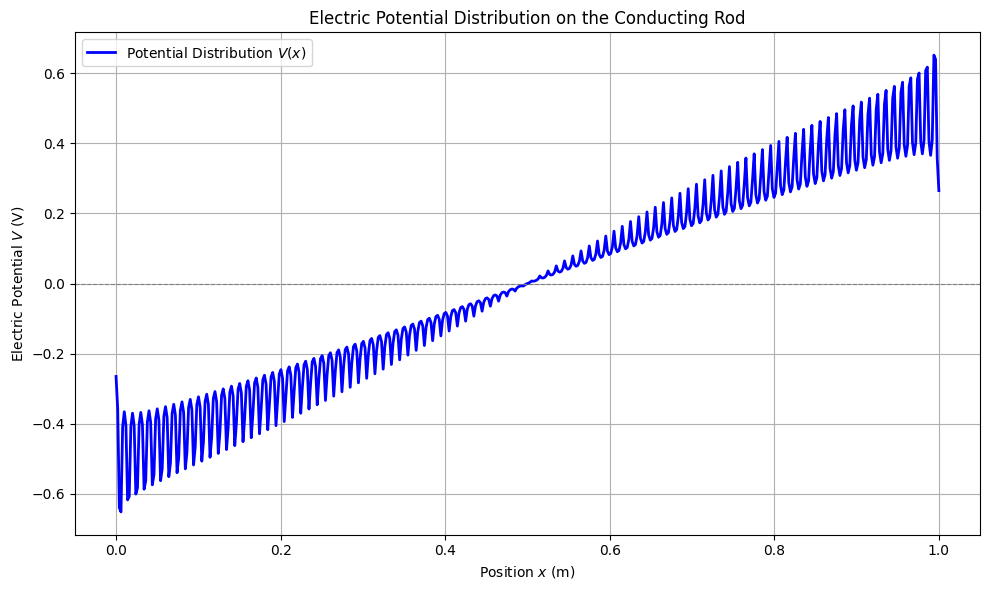


--- Potential Distribution Analysis ---
Minimum Potential: -6.5164e-01 V
Maximum Potential: 6.5164e-01 V
Potential at x=0 (left end): -2.6510e-01 V
Potential at x=L (right end): 2.6510e-01 V


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 기존 시뮬레이션에서 가져올 값 (가정) ---

# 0. 필수 물리 상수 및 변수 (기존 코드에서 가져옴)
epsilon_0 = 8.854e-12  # 진공의 유전율 (F/m)
L = 1.0              # 막대의 길이 (m)
# N = 100            # <--- 이 라인 주석 처리 또는 삭제
dx_segment = L / 100.0 # dx_segment 계산을 위한 기준 N (100)
a_offset_for_potential = 1e-3 # 전위 계산을 위한 작은 등가 반지름 (m).

# MoM 시뮬레이션에서 계산된 최종 전하 계수 (Q_j 값)
# 이 'charge_coeffs' 변수는 앞선 MoM 코드가 실행된 후 메모리에 존재해야 합니다.
# 만약 없다면, MoM 코드를 먼저 실행하여 이 값을 생성하세요.
if 'charge_coeffs' not in locals():
    print("Error: 'charge_coeffs' variable not found. Please run the previous MoM simulation code first.")
    # 실제 환경에서는 여기서 스크립트를 종료하거나 오류를 명확히 처리해야 합니다.
    # 예시를 위해 더미 값 생성 (실제 사용 시 제거!)
    L = 1.0
    N_dummy = 100
    dx_segment_dummy = L / N_dummy
    x_charge_basis_centers = np.linspace(dx_segment_dummy / 2, L - dx_segment_dummy / 2, N_dummy)
    charge_coeffs = np.sin(x_charge_basis_centers * np.pi / L) * 1e-12
    print("Using dummy charge_coeffs for demonstration.")

# 실제 전하 계수 배열의 길이를 N_charges로 설정
N_charges = len(charge_coeffs)
# x_charge_basis_centers도 N_charges에 맞춰 다시 생성 (혹시 모를 불일치 방지)
dx_segment_actual = L / N_charges
x_charge_basis_centers = np.linspace(dx_segment_actual / 2, L - dx_segment_actual / 2, N_charges)

print(f"Calculating potential distribution using {N_charges} point charges...")

# --- 1. 전위를 평가할 위치 정의 ---
num_potential_points = 500 # 전위 평가 지점 수
x_potential_points = np.linspace(0, L, num_potential_points)

# --- 2. 전위 계산 함수 ---
def calculate_potential(x_eval_point, charge_positions, charge_values, epsilon0, offset_a):
    potential = 0.0
    for j in range(len(charge_values)): # charge_values의 길이만큼 루프를 돕니다.
        r_squared = (x_eval_point - charge_positions[j])**2 # charge_positions도 같은 길이라고 가정
        denominator = np.sqrt(r_squared + offset_a**2)

        # 수치적 안정성을 위해 0으로 나누는 것을 방지
        if denominator < 1e-18:
            # 여기서는 극히 작은 값으로 대체하거나 해당 항을 건너뛰는 전략을 사용할 수 있으나
            # offset_a 덕분에 분모가 0이 될 일은 거의 없습니다.
            # 문제가 발생하지 않는 이상 pass 유지
            pass

        potential += charge_values[j] / denominator

    return potential / (4 * np.pi * epsilon0)

# --- 3. 각 평가 지점에서 전위 계산 ---
potential_distribution = np.zeros(num_potential_points)

for i, x_point in enumerate(x_potential_points):
    potential_distribution[i] = calculate_potential(
        x_point, x_charge_basis_centers, charge_coeffs, epsilon_0, a_offset_for_potential
    )

print("Potential distribution calculation complete.")

# --- 4. 전위 분포 플로팅 ---
plt.figure(figsize=(10, 6))
plt.plot(x_potential_points, potential_distribution, 'b-', linewidth=2, label='Potential Distribution $V(x)$')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8) # 0 전위선

plt.title('Electric Potential Distribution on the Conducting Rod')
plt.xlabel('Position $x$ (m)')
plt.ylabel('Electric Potential $V$ (V)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 5. 추가 분석 ---
print("\n--- Potential Distribution Analysis ---")
print(f"Minimum Potential: {np.min(potential_distribution):.4e} V")
print(f"Maximum Potential: {np.max(potential_distribution):.4e} V")
print(f"Potential at x=0 (left end): {potential_distribution[0]:.4e} V")
print(f"Potential at x=L (right end): {potential_distribution[-1]:.4e} V")

# 주변 공간의 전위 분포 및 전기력선 분포

<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-1432658590.py:94: SyntaxWarning: invalid escape sequence '\l'
  plt.colorbar(label='Electric Field Magnitude $\log_{10}|E|$ (V/m)')



--- Visualizing Electric Field Lines and Potential in 2D Space (Custom Colormap) ---
Calculating potential and electric field on 2D grid...
Calculation complete.


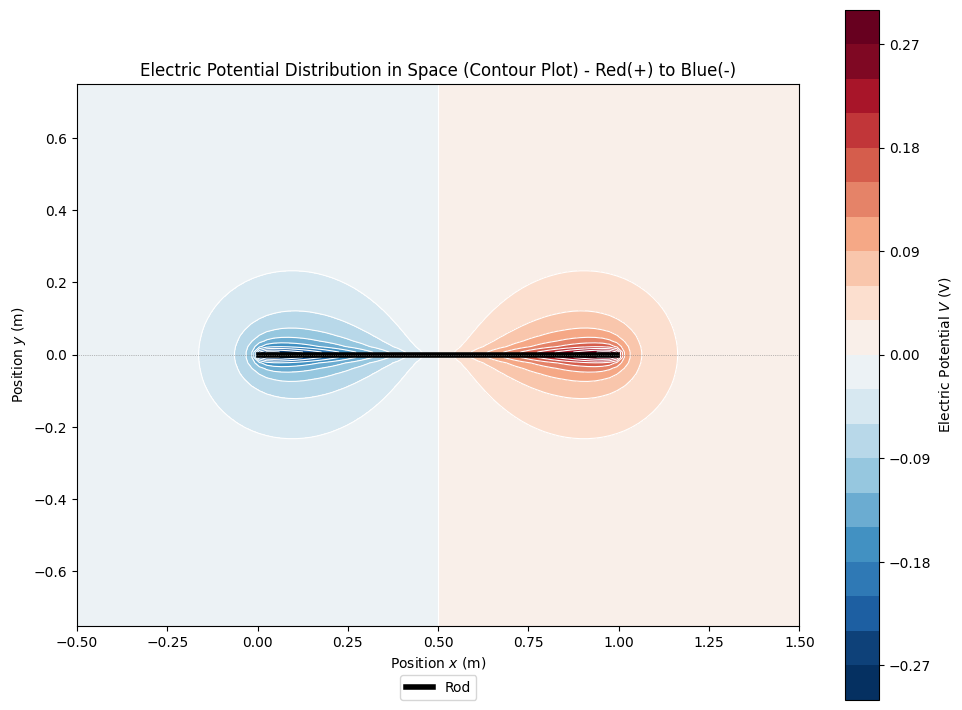

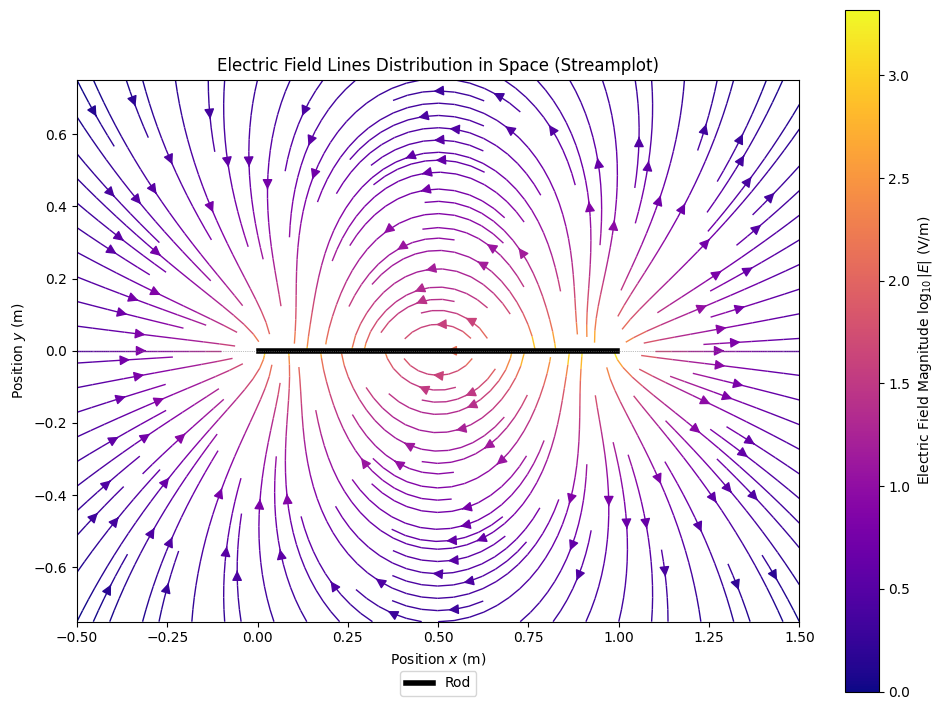

2D spatial visualization complete. Observe the field lines and equipotential lines.
The electric field lines should emanate from positive charges and terminate on negative charges.
Equipotential lines should be perpendicular to electric field lines.


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --- 기존 시뮬레이션에서 가져올 값 (가정) ---
# epsilon_0 = 8.854e-12  # 진공의 유전율 (F/m)
# L = 1.0              # 막대의 길이 (m)

# MoM 시뮬레이션에서 계산된 최종 전하 계수 (Q_j 값)
if 'charge_coeffs' not in locals():
    print("Error: 'charge_coeffs' variable not found. Please run the previous MoM simulation code first.")
    exit()

N_charges = len(charge_coeffs)
dx_segment_actual = L / N_charges
x_charge_basis_centers = np.linspace(dx_segment_actual / 2, L - dx_segment_actual / 2, N_charges)

# 전위/전기장 계산에 사용될 작은 등가 반지름 (수치적 안정성을 위해 필요)
a_offset_for_spatial_viz = 1e-3

print(f"\n--- Visualizing Electric Field Lines and Potential in 2D Space (Custom Colormap) ---")

# --- 1. 2D 공간 그리드 정의 ---
x_min, x_max = -.5*L, 1.5*L
y_min, y_max = -0.75 * L, 0.75 * L
num_x_points = 100
num_y_points = 100
x_grid = np.linspace(x_min, x_max, num_x_points)
y_grid = np.linspace(y_min, y_max, num_y_points)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)

# --- 2. 각 그리드 점에서 전위 및 전기장 계산 함수 (이전과 동일) ---
def calculate_spatial_potential_and_field(x_eval, y_eval, charge_positions, charge_values, epsilon0, offset_a):
    potential = np.zeros_like(x_eval, dtype=float)
    Ex = np.zeros_like(x_eval, dtype=float)
    Ey = np.zeros_like(x_eval, dtype=float)

    for j in range(len(charge_values)):
        qx = charge_positions[j]
        Qj = charge_values[j]
        r_squared = (x_eval - qx)**2 + y_eval**2 + offset_a**2
        r = np.sqrt(r_squared)
        potential += Qj / r
        r_cubed = r_squared * r
        Ex += Qj * (x_eval - qx) / r_cubed
        Ey += Qj * y_eval / r_cubed

    potential /= (4 * np.pi * epsilon0)
    Ex /= (4 * np.pi * epsilon0)
    Ey /= (4 * np.pi * epsilon0)
    return potential, Ex, Ey

# --- 3. 그리드 전체에 걸쳐 계산 실행 ---
print("Calculating potential and electric field on 2D grid...")
V_spatial, Ex_spatial, Ey_spatial = calculate_spatial_potential_and_field(
    X_mesh, Y_mesh, x_charge_basis_centers, charge_coeffs, epsilon_0, a_offset_for_spatial_viz
)
print("Calculation complete.")

# --- 4. 전위 등고선 플롯 (Contour Plot) - 컬러맵 변경 ---
plt.figure(figsize=(10, 8))
contour_levels = 20 # 등고선 개수

# V_spatial의 min/max 값 중 절댓값이 큰 것을 기준으로 vmax/vmin 설정
# 이렇게 해야 0을 중심으로 컬러맵이 대칭적으로 적용됩니다.
abs_max_V = np.max(np.abs(V_spatial))
vmin_val = -abs_max_V
vmax_val = abs_max_V

plt.contourf(X_mesh, Y_mesh, V_spatial, levels=contour_levels, cmap='RdBu_r', vmin=vmin_val, vmax=vmax_val) # <--- 여기 수정
plt.colorbar(label='Electric Potential $V$ (V)')
plt.contour(X_mesh, Y_mesh, V_spatial, levels=contour_levels, colors='white', linestyles='solid', linewidths=0.8)

# 막대 그리기
plt.plot(x_charge_basis_centers, np.zeros_like(x_charge_basis_centers), 'k-', linewidth=4, label='Rod')
#plt.scatter(x_charge_basis_centers, np.zeros_like(x_charge_basis_centers), c=charge_coeffs, cmap='coolwarm', s=50, edgecolors='k', label='Point Charges')

plt.title('Electric Potential Distribution in Space (Contour Plot) - Red(+) to Blue(-)')
plt.xlabel('Position $x$ (m)')
plt.ylabel('Position $y$ (m)')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# --- 5. 전기장력선 플롯 (Streamplot) - 이전과 동일 ---
plt.figure(figsize=(10, 8))
E_magnitude = np.sqrt(Ex_spatial**2 + Ey_spatial**2)
E_min = E_magnitude.min()
E_log = np.log10(E_magnitude / E_min)
plt.streamplot(X_mesh, Y_mesh, Ex_spatial, Ey_spatial,
               color=E_log, cmap='plasma', linewidth=1, density=1.5, arrowsize=1.5)

plt.colorbar(label='Electric Field Magnitude $\log_{10}|E|$ (V/m)')

# 막대 그리기
plt.plot(x_charge_basis_centers, np.zeros_like(x_charge_basis_centers), 'k-', linewidth=4, label='Rod')
#plt.scatter(x_charge_basis_centers, np.zeros_like(x_charge_basis_centers), c=charge_coeffs, cmap='coolwarm', s=50, edgecolors='k')

plt.title('Electric Field Lines Distribution in Space (Streamplot)')
plt.xlabel('Position $x$ (m)')
plt.ylabel('Position $y$ (m)')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

print("2D spatial visualization complete. Observe the field lines and equipotential lines.")
print("The electric field lines should emanate from positive charges and terminate on negative charges.")
print("Equipotential lines should be perpendicular to electric field lines.")